<a href="https://colab.research.google.com/github/devopsgeospatial/Building-Inspection/blob/main/Building_Detection_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Detection — Mask R-CNN Training
**Fine-tunes a Mask R-CNN model on your Kigali building dataset using a free T4 GPU.**

### Before running:
1. Upload `building_detection_colab.zip` to your Google Drive
2. Make sure Runtime > Change runtime type > **T4 GPU** is selected
3. Run cells top to bottom

## Step 1 — Check GPU

In [1]:
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu}')
    print(f'VRAM: {mem:.1f} GB')
    print('CUDA ready.')
else:
    print('No GPU found. Go to Runtime > Change runtime type > T4 GPU')

GPU: Tesla T4
VRAM: 15.6 GB
CUDA ready.


## Step 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted at /content/drive')

Mounted at /content/drive
Drive mounted at /content/drive


## Step 3 — Find and Extract Training Data
Looks for `building_detection_colab.zip` anywhere in your Drive.

In [3]:
import os, glob, zipfile

# Find the zip in Drive
matches = glob.glob('/content/drive/**/*building_detection_colab*.zip', recursive=True)

if not matches:
    print('ZIP not found in Drive.')
    print('Please upload building_detection_colab.zip to Google Drive first.')
else:
    zip_path = matches[0]
    print(f'Found: {zip_path}')
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f'Size: {size_mb:.1f} MB')

    print('Extracting...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall('/content/building_detection')

    # Verify
    import json
    idx = json.load(open('/content/building_detection/training_data/dataset.json'))
    print(f'\nDataset loaded:')
    print(f'  Total patches  : {idx["total_patches"]}')
    print(f'  Positive       : {idx["positive_patches"]}')
    print(f'  Negative       : {idx["negative_patches"]}')
    print(f'  Patch size     : {idx["patch_size"]} px')
    print(f'  Resolution     : {idx["resolution_mpp"]:.4f} m/px')

Found: /content/drive/MyDrive/building_detection_colab.zip
Size: 26.8 MB
Extracting...

Dataset loaded:
  Total patches  : 58
  Positive       : 58
  Negative       : 0
  Patch size     : 512 px
  Resolution     : 0.2986 m/px


## Step 4 — Install Dependencies

In [4]:
# torch and torchvision are pre-installed on Colab
# just verify versions
import torch, torchvision
print(f'torch       : {torch.__version__}')
print(f'torchvision : {torchvision.__version__}')
print(f'CUDA        : {torch.version.cuda}')

torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
CUDA        : 12.8


## Step 5 — Configure Training

In [5]:
# ---- Edit these if needed ----
EPOCHS     = 50      # more epochs than local run - GPU is fast
BATCH      = 4       # T4 has 16GB VRAM, can handle batch 4
LR         = 0.001
FREEZE     = 5       # freeze backbone for first 5 epochs
VAL_SPLIT  = 0.15
WORKERS    = 2       # Colab has 2 CPU cores for data loading
# ------------------------------

DATA_DIR   = '/content/building_detection/training_data'
OUTPUT_DIR = '/content/building_detection/checkpoints'
TRAIN_PY   = '/content/building_detection/train.py'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config ready.')
print(f'  Epochs : {EPOCHS}')
print(f'  Batch  : {BATCH}')
print(f'  Device : cuda ({torch.cuda.get_device_name(0)})')

Config ready.
  Epochs : 50
  Batch  : 4
  Device : cuda (Tesla T4)


## Step 6 — Run Training
Watch the loss drop in real time. Each epoch should take **20-40 seconds** on T4.

In [6]:
import subprocess, sys

cmd = [
    sys.executable, TRAIN_PY,
    '-d', DATA_DIR,
    '-o', OUTPUT_DIR,
    '--epochs',    str(EPOCHS),
    '--batch',     str(BATCH),
    '--lr',        str(LR),
    '--freeze',    str(FREEZE),
    '--val-split', str(VAL_SPLIT),
    '--device',    'cuda',
    '--workers',   str(WORKERS),
]

print('Starting training...')
print(' '.join(cmd))
print('-' * 55)

proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True, bufsize=1
)
for line in proc.stdout:
    print(line, end='')
proc.wait()

if proc.returncode == 0:
    print('\nTraining complete.')
else:
    print(f'\nTraining exited with code {proc.returncode}')

Starting training...
/usr/bin/python3 /content/building_detection/train.py -d /content/building_detection/training_data -o /content/building_detection/checkpoints --epochs 50 --batch 4 --lr 0.001 --freeze 5 --val-split 0.15 --device cuda --workers 2
-------------------------------------------------------
  Building Detector -- Training

[1/4] Loading dataset: /content/building_detection/training_data
  Total patches : 58
  Positive      : 58
  Negative      : 0
  Train split   : 50
  Val split     : 8

[2/4] Building model ...
  Starting from ImageNet pretrained weights ...
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth

  0%|          | 0.00/170M [00:00<?, ?B/s]
  8%|▊         | 14.4M/170M [00:00<00:01, 151MB/s]
 22%|██▏       | 38.0M/170M [00:00<00:00, 207MB/s]
 34%|███▍      | 57.8M/170M [00:00<00:00, 207MB/s]
 46%|████▌     | 77.5M/170M [00:00<00:00, 206MB/s]
 5

## Step 7 — Review Loss Curve

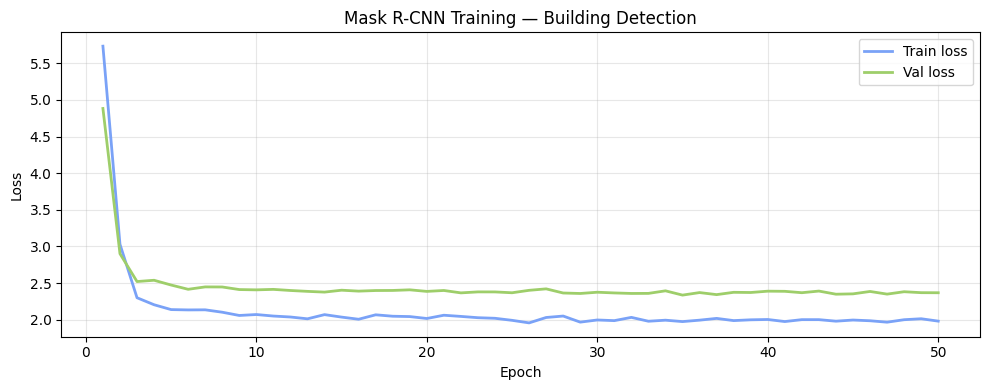

Best epoch : 35
Best val   : 2.3358
Train loss : 1.9743


In [7]:
import json
import matplotlib.pyplot as plt

log = json.load(open(f'{OUTPUT_DIR}/training_log.json'))

epochs   = [e['epoch']    for e in log]
trn_loss = [e['trn_loss'] for e in log]
val_loss = [e['val_loss'] for e in log]

plt.figure(figsize=(10, 4))
plt.plot(epochs, trn_loss, label='Train loss', color='#7aa2f7', linewidth=2)
plt.plot(epochs, val_loss, label='Val loss',   color='#9ece6a', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Mask R-CNN Training — Building Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best = min(log, key=lambda e: e['val_loss'])
print(f"Best epoch : {best['epoch']}")
print(f"Best val   : {best['val_loss']:.4f}")
print(f"Train loss : {best['trn_loss']:.4f}")

## Step 8 — Save best_model.pth to Google Drive

In [8]:
import shutil

# Save to Drive so it persists after the Colab session ends
drive_out = '/content/drive/MyDrive/Building_Detection'
os.makedirs(drive_out, exist_ok=True)

src = f'{OUTPUT_DIR}/best_model.pth'
dst = f'{drive_out}/best_model_colab.pth'

shutil.copy(src, dst)
size_mb = os.path.getsize(dst) / 1e6
print(f'Saved to Google Drive: {dst}')
print(f'Size: {size_mb:.1f} MB')

# Also copy training log
shutil.copy(f'{OUTPUT_DIR}/training_log.json',
            f'{drive_out}/training_log_colab.json')
print('Training log saved too.')
print(f'\nDownload best_model_colab.pth from Google Drive')
print(f'Then use it in building_detector_gui.py with -m flag')

Saved to Google Drive: /content/drive/MyDrive/Building_Detection/best_model_colab.pth
Size: 176.2 MB
Training log saved too.

Download best_model_colab.pth from Google Drive
Then use it in building_detector_gui.py with -m flag


## Step 9 — Download directly to your computer (alternative)

In [9]:
from google.colab import files

# This triggers a browser download
files.download(f'{OUTPUT_DIR}/best_model.pth')
files.download(f'{OUTPUT_DIR}/training_log.json')
print('Download started in your browser.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started in your browser.
